# **Movie Memory Experiment**

**Authors:** Arkadipta Das, Rohan Karmakar, Mahima Chakraborty



In [1]:
# Installing necessary packages (will take some time)
install.packages("openxlsx")
install.packages("effsize")
install.packages("rstatix")
install.packages('coin')

Installing package into 'C:/Users/Mahima/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'openxlsx' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Mahima\AppData\Local\Temp\Rtmp4eZyqv\downloaded_packages


Installing package into 'C:/Users/Mahima/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'effsize' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Mahima\AppData\Local\Temp\Rtmp4eZyqv\downloaded_packages


Installing package into 'C:/Users/Mahima/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'rstatix' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Mahima\AppData\Local\Temp\Rtmp4eZyqv\downloaded_packages


Installing package into 'C:/Users/Mahima/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'coin' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Mahima\AppData\Local\Temp\Rtmp4eZyqv\downloaded_packages


In [2]:
# necessary libraries
library(ggplot2)
library(readr)
library(dplyr)
library(readxl)
library(tidyverse)
library(openxlsx)
library(stats)
library(effsize)
library(rstatix)
library(coin)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'rstatix'


The following object is masked from 'package:stats':

    filter


Loading required package: survival


Attaching package: 'coin'


The following objects are masked from 'package:rstatix':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




In [3]:
zip_file_path <- "./BRSM data csv.zip"
extraction_path <- "./BRSM data csv"

# Unzip the file
unzip(zip_file_path, exdir = extraction_path)

print(paste("File '", zip_file_path, "' unzipped to '", extraction_path, "'", sep = ""))

[1] "File './BRSM data csv.zip' unzipped to './BRSM data csv'"


In [4]:
path = "./BRSM data csv/BRSM data csv/BRSM data csv"
all_files = list.files(path, pattern = "*.csv", full.names = TRUE)

In [5]:
abrupt_files <- grep("AB", all_files, value = TRUE)
natural_files <- grep("NB", all_files, value = TRUE)
print(paste("Abrupt subjects:", length(abrupt_files)))
print(paste("Natural subjects:", length(natural_files)))

[1] "Abrupt subjects: 81"


[1] "Natural subjects: 90"


In [6]:
combined_files <- c(abrupt_files, natural_files)
length(combined_files)

[1] 171

In [7]:
head(combined_files)

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"
[2] "./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv"
[3] "./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv"
[4] "./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv"
[5] "./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv"
[6] "./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv"

In [8]:
abrupt <- read.csv("./BRSM data csv/BRSM data csv/abruptmovies.csv")
head(abrupt)

,path,duration,is_repeat
,<chr>,<int>,<int>
1,abrupt_videos\abrupt_1.mp4,17,0
2,abrupt_videos\abrupt_2.mp4,31,0
3,abrupt_videos\abrupt_3.mp4,27,1
4,abrupt_videos\abrupt_3.mp4,27,1
5,abrupt_videos\abrupt_4.mp4,32,0
6,abrupt_videos\abrupt_5.mp4,33,0


In [9]:
natural <- read.csv("./BRSM data csv/BRSM data csv/naturalmovies.csv")
head(natural)

,path,duration,is_repeat
,<chr>,<int>,<int>
1,Trimmed_videos/natural_1.mp4,19,0
2,Trimmed_videos/natural_2.mp4,31,0
3,Trimmed_videos/natural_3.mp4,28,1
4,Trimmed_videos/natural_3.mp4,28,1
5,Trimmed_videos/natural_4.mp4,31,0
6,Trimmed_videos/natural_5.mp4,33,0


In [10]:
targets_lures <- read.csv("./BRSM data csv/BRSM data csv/target_and_lures.csv")
head(targets_lures)

,movie_id,target_img,lure_img
,<int>,<chr>,<chr>
1,1,frames\Vid1_EM_T.png,frames\Vid1_L.png
2,2,frames\Vid2_BB_T.png,frames\Vid2_L.png
3,3,frames\Vid3_BB_T.png,frames\Vid3_L.png
4,4,frames\Vid4_EM_T.png,frames\Vid4_L.png
5,5,frames\Vid5_EM_T.png,frames\Vid5_L.png
6,6,frames\Vid6_BB_T.png,frames\Vid6_L.png


In [11]:
em_count <- sum(grepl("EM", targets_lures$target_img))

# Count how many filenames contain "BB"
bb_count <- sum(grepl("BB", targets_lures$target_img))

# Print results
cat("Number of targets with 'EM':", em_count, "\n")
cat("Number of targets with 'BB':", bb_count, "\n")

Number of targets with 'EM': 20 
Number of targets with 'BB': 20 


In [12]:
# Demographic data
demo_data <- as.data.frame(read_excel("./BRSM data csv/BRSM data csv/Demographic data.xlsx"))

In [13]:
head(demo_data)

,Sub ID,Age,Gender,Handedness,Vision
,<chr>,<dbl>,<chr>,<chr>,<chr>
1,sub34_AB,22,Female,Right handed,Corrected to normal
2,sub23_AB,21,Female,Right handed,Normal
3,sub46_NB,20,Female,Right handed,Corrected to normal
4,sub72_NB,28,Male,Right handed,Corrected to normal
5,sub150_NB,27,Male,Right handed,Normal
6,sub162_NB,23,Male,Right handed,Normal


In [14]:
length(demo_data$`Sub ID`)

[1] 185

In [15]:
# Get subjects for which data has been provided
subjects <- str_extract(combined_files, "[Ss]ub\\d+_[A-Z]+")
sort(subjects)

[1] "sub100_AB" "sub101_AB" "sub102_AB" "sub103_AB" "sub104_AB" "sub105_AB"
  [7] "sub106_AB" "sub107_AB" "sub108_AB" "sub109_AB" "sub110_AB" "sub111_AB"
 [13] "sub112_AB" "sub113_AB" "sub114_AB" "sub115_AB" "sub116_AB" "sub117_AB"
 [19] "sub118_AB" "sub119_AB" "sub120_AB" "sub121_AB" "sub122_AB" "sub123_AB"
 [25] "sub124_AB" "sub125_AB" "sub126_AB" "sub127_AB" "sub128_AB" "sub129_AB"
 [31] "sub130_AB" "sub131_AB" "sub132_AB" "sub133_AB" "sub134_AB" "sub135_AB"
 [37] "sub136_AB" "sub137_AB" "sub138_AB" "sub139_AB" "sub14_NB"  "sub140_AB"
 [43] "sub141_AB" "sub142_AB" "sub143_AB" "sub144_AB" "sub145_AB" "sub146_AB"
 [49] "sub147_AB" "sub148_AB" "sub149_AB" "sub15_NB"  "sub150_NB" "sub151_NB"
 [55] "sub152_NB" "sub153_NB" "sub154_NB" "sub155_NB" "sub156_NB" "sub157_AB"
 [61] "sub158_NB" "sub159_NB" "sub16_NB"  "sub160_NB" "sub161_NB" "sub162_NB"
 [67] "sub163_NB" "sub164_NB" "sub165_NB" "sub166_NB" "sub167_NB" "sub168_NB"
 [73] "sub169_NB" "sub17_NB"  "sub170_NB" "sub171_NB" "sub172_NB" "sub173_NB"
 [79] "sub174_NB" "sub175_NB" "sub176_NB" "sub177_NB" "sub178_NB" "sub179_NB"
 [85] "sub18_NB"  "sub180_NB" "sub181_NB" "sub182_NB" "sub183_NB" "sub184_NB"
 [91] "sub185_NB" "sub19_NB"  "sub21_NB"  "sub22_NB"  "sub23_AB"  "sub24_NB" 
 [97] "sub25_AB"  "sub26_AB"  "sub27_AB"  "sub28_AB"  "sub29_AB"  "sub30_AB" 
[103] "sub31_AB"  "sub32_AB"  "sub33_AB"  "sub34_AB"  "sub35_AB"  "sub36_AB" 
[109] "sub37_AB"  "sub38_AB"  "sub39_AB"  "sub40_AB"  "Sub41_AB"  "sub42_NB" 
[115] "Sub43_NB"  "sub44_NB"  "sub45_NB"  "sub46_NB"  "sub47_NB"  "sub48_NB" 
[121] "sub49_NB"  "sub50_NB"  "sub51_NB"  "sub52_NB"  "sub53_NB"  "sub54_NB" 
[127] "sub55_NB"  "sub56_NB"  "sub57_NB"  "sub58_NB"  "sub59_NB"  "sub60_NB" 
[133] "sub61_NB"  "sub62_NB"  "sub63_NB"  "sub64_NB"  "sub65_NB"  "sub66_NB" 
[139] "sub67_NB"  "sub68_NB"  "sub69_NB"  "sub70_NB"  "sub71_NB"  "sub72_NB" 
[145] "sub73_NB"  "sub74_NB"  "sub75_NB"  "sub76_NB"  "sub77_NB"  "sub78_NB" 
[151] "sub79_NB"  "sub80_NB"  "sub81_NB"  "sub82_NB"  "sub83_NB"  "sub84_NB" 
[157] "sub85_NB"  "sub86_NB"  "sub87_NB"  "sub88_AB"  "sub89_AB"  "sub90_AB" 
[163] "sub91_AB"  "sub92_AB"  "sub93_AB"  "sub94_AB"  "sub95_AB"  "sub96_AB" 
[169] "sub97_AB"  "sub98_AB"  "sub99_AB"

In [16]:
demo_data_filtered <- demo_data %>%
  filter(`Sub ID` %in% subjects)
length(demo_data_filtered$`Sub ID`)

[1] 165

6 subjects present in analysis files are missing from the demographics spreadsheet.

In [17]:
table(demo_data_filtered$Gender)


Female   Male 
    44    104 

In [18]:
any(is.na(demo_data_filtered))

[1] TRUE

In [19]:
sum(!complete.cases(demo_data_filtered))

[1] 17

In [20]:
# incomplete demo data
demo_data_filtered[!complete.cases(demo_data_filtered),]

,Sub ID,Age,Gender,Handedness,Vision
,<chr>,<dbl>,<chr>,<chr>,<chr>
13,sub49_NB,NA,NA,NA,NA
22,sub175_NB,NA,NA,NA,NA
23,sub80_NB,NA,NA,NA,NA
29,sub66_NB,NA,NA,NA,NA
30,sub39_AB,NA,NA,NA,NA
43,sub19_NB,NA,NA,NA,NA
53,sub117_AB,NA,NA,NA,NA
88,sub146_AB,NA,NA,NA,NA
100,sub178_NB,NA,NA,NA,NA


In [21]:
# replace NA with mean age, mode for gender, handedness and vision
demo_data_filtered$Age[is.na(demo_data_filtered$Age)] <- mean(demo_data_filtered$Age, na.rm = TRUE)
demo_data_filtered$Gender[is.na(demo_data_filtered$Gender)] <- names(table(demo_data_filtered$Gender))[which.max(table(demo_data_filtered$Gender))]
demo_data_filtered$Handedness[is.na(demo_data_filtered$Handedness)] <- names(table(demo_data_filtered$Handedness))[which.max(table(demo_data_filtered$Handedness))]
demo_data_filtered$Vision[is.na(demo_data_filtered$Vision)] <- names(table(demo_data_filtered$Vision))[which.max(table(demo_data_filtered$Vision))]

In [22]:
any(!complete.cases(demo_data_filtered))

[1] FALSE

In [23]:
nrow(demo_data_filtered)

[1] 165

In [24]:
# list 6 subjects missing in demo data
missing_subjects <- setdiff(subjects, demo_data_filtered$`Sub ID`)
print("Subjects missing in demo data:")
print(missing_subjects)

[1] "Subjects missing in demo data:"
[1] "sub157_AB" "sub38_AB"  "Sub41_AB"  "Sub43_NB"  "sub86_NB"  "sub87_NB" 


In [25]:
# add demo data for the 6 subjects missing in the same manner
gender_mode <- names(table(demo_data_filtered$Gender))[which.max(table(demo_data_filtered$Gender))]
handedness_mode <- names(table(demo_data_filtered$Handedness))[which.max(table(demo_data_filtered$Handedness))]
vision_mode <- names(table(demo_data_filtered$Vision))[which.max(table(demo_data_filtered$Vision))]
demo_data_filtered <- rbind(demo_data_filtered, data.frame(`Sub ID` = missing_subjects,
                                                            Age = mean(demo_data_filtered$Age, na.rm = TRUE),
                                                            Gender = gender_mode,
                                                            Handedness = handedness_mode,
                                                            Vision = vision_mode,
                                                            check.names = FALSE))    


In [26]:
nrow(demo_data_filtered)

[1] 171

In [27]:
summary(demo_data_filtered$Age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  19.00   21.00   22.24   22.24   23.00   28.00 

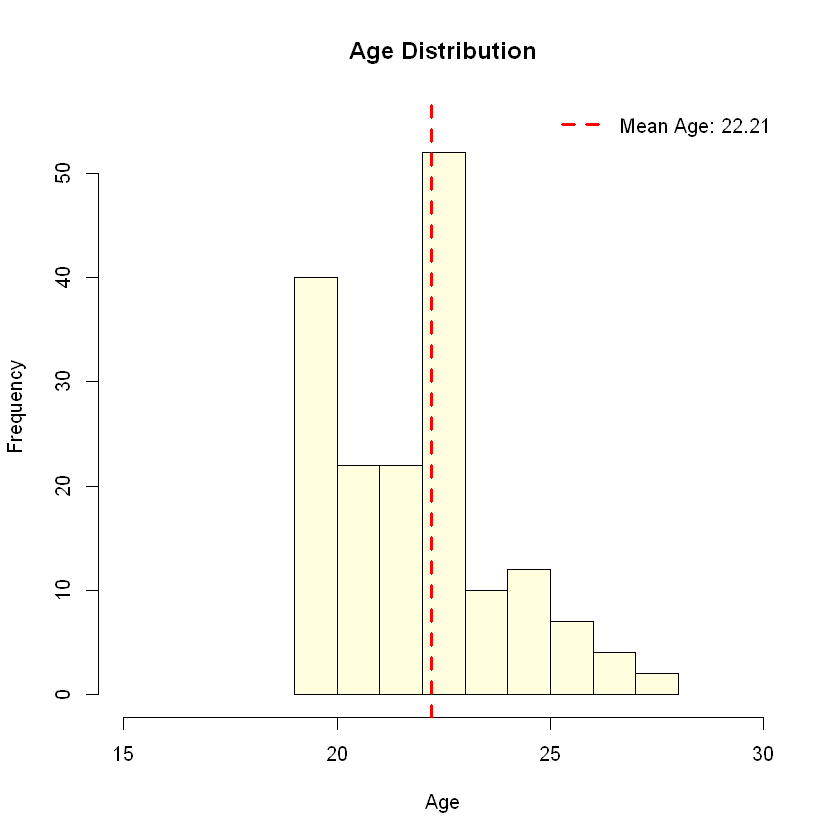

In [28]:
hist(demo_data_filtered$Age, 
     main = "Age Distribution",
     xlab = "Age",
     ylab = "Frequency",
     col = "lightyellow",
     border = "black",
     xlim = c(15, 30),
     ylim = c(0, 55))
abline(v = 22.21, col = "red", lwd = 3, lty = 2)
legend("topright", legend = paste("Mean Age:", round(22.21, 2)),
       col = "red", lwd = 3, lty = 2, bty = "n")

In [29]:
table(demo_data_filtered$Handedness)


 Left Handed Right handed 
           8          163 

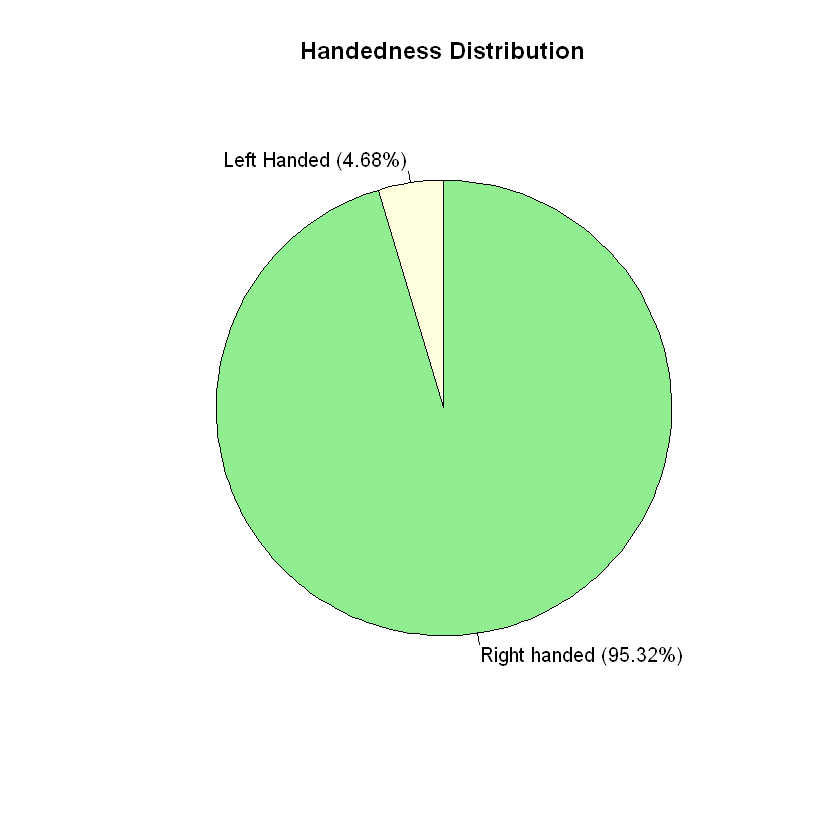

In [30]:
# Distribution of handedness

handedness_counts <- as.data.frame(table(demo_data_filtered$Handedness))
colnames(handedness_counts) <- c("Handedness", "Count")
handedness_counts$Percent <- round((handedness_counts$Count / sum(handedness_counts$Count)) * 100, 2)
# pie chart

pie(handedness_counts$Percent,
    labels = paste(handedness_counts$Handedness, " (", handedness_counts$Percent, "%)", sep = ""),
    main = "Handedness Distribution",
    col = c("lightyellow", "lightgreen"),
    init.angle = 90
    )

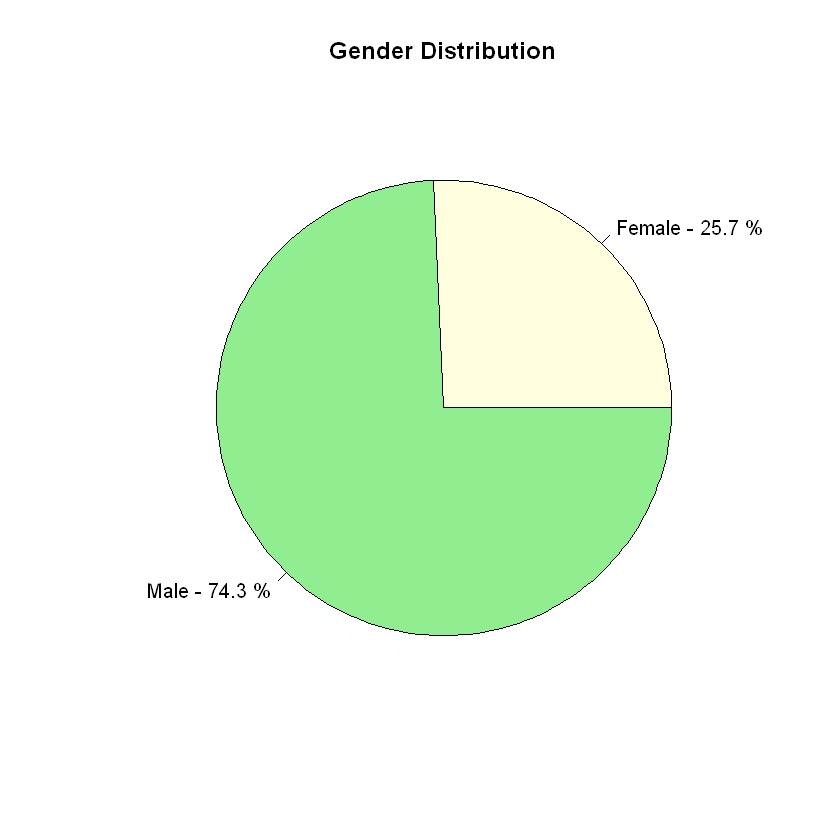

In [31]:
# Gender distribution
gender_counts <- as.data.frame(table(demo_data_filtered$Gender))
colnames(gender_counts) <- c("Gender","Count")
gender_counts$Percent <- round((gender_counts$Count / sum(gender_counts$Count)) * 100, 2)

pie(gender_counts$Percent,
    labels = paste(gender_counts$Gender, "-", round(gender_counts$Percent,1), "%"),
    main = "Gender Distribution",
    col = c("lightyellow", "lightgreen"))

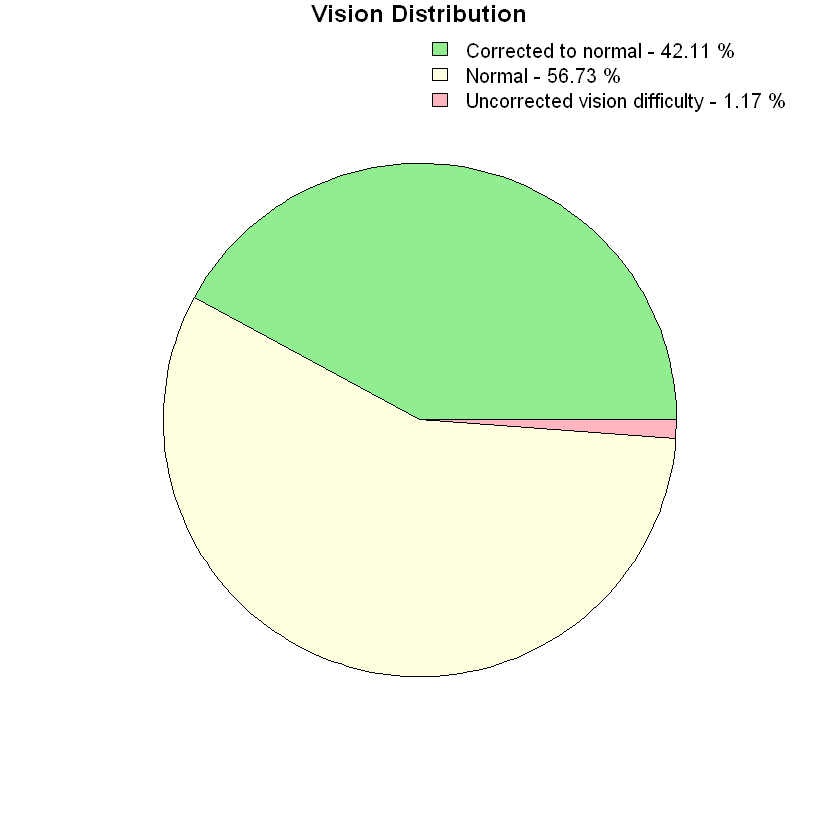

In [32]:
# Vision distribution
vision_counts <- as.data.frame(table(demo_data_filtered$Vision))
colnames(vision_counts) <- c("Vision","Count")
vision_counts$Percent <- round((vision_counts$Count / sum(vision_counts$Count)) * 100, 2)

par(mar = c(1, 1, 1, 1))
pie(vision_counts$Percent,
    labels = NA,
    main = "Vision Distribution",
    col = c("lightgreen", "lightyellow", "lightpink"),
    radius = 0.7)
legend("topright", 
       legend = paste(vision_counts$Vision, "-", vision_counts$Percent, "%"), 
       fill = c("lightgreen", "lightyellow", "lightpink"),
       cex = 1,
       bty = "n")



## Exploratory Data Analysis


In [33]:
abrupt_files[1]

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"

In [34]:
# test one abrupt file
df_test <- read.csv(abrupt_files[1])
df_test_clean <- df_test %>%
  select(resp.corr) %>%
  filter(!is.na(resp.corr))

df_test_clean$resp.corr <- as.numeric(df_test_clean$resp.corr)
dim(df_test_clean)[1]
sum(df_test_clean == 1)

[1] 40

[1] 39

In [35]:
# test one natural file
df_test_2 <- read.csv(natural_files[1])
df_test_clean_2 <- df_test_2 %>%
  select(resp.corr) %>%
  filter(!is.na(resp.corr))

df_test_clean_2$resp.corr <- as.numeric(df_test_clean_2$resp.corr)
dim(df_test_clean_2)[1]
sum(df_test_clean_2 == 1)

# natural_files[1]

[1] 40

[1] 33

In [36]:
# Function to check for 'resp.corr' column in all files
check_resp_corr <- function(filepath) {
  df <- read.csv(filepath)
  if (!"resp.corr" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_resp_corr <- lapply(combined_files, check_resp_corr)
missing_resp_corr <- unlist(missing_resp_corr[!sapply(missing_resp_corr, is.null)])

if (length(missing_resp_corr) > 0) {
  print("Files missing 'resp.corr' column:")
  print(missing_resp_corr)
} else {
  print("All files contain 'resp.corr' column.")
}

[1] "Files missing 'resp.corr' column:"
[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv"


In [37]:
test <- read.csv("./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv")
colnames(test)

[1] "thisRow.t"            "notes"                "age"                 
 [4] "gender"               "handedness"           "vision"              
 [7] "caffeine_2h"          "alcohol_smoke_12h"    "demographics.started"
[10] "demographics.stopped" "Instructions.started" "text1.started"       
[13] "key_resp.started"     "participant"          "session"             
[16] "date"                 "expName"              "expVersion"          
[19] "psychopyVersion"      "frameRate"            "expStart"            
[22] "X"

The file: sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv does not contain the data necessary for the analysis as seen above. Therefore, it was excluded from the analysis.

In [38]:
natural_files <- natural_files[natural_files != "./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv"]

In [39]:
combined_files <- combined_files[combined_files != "./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv"]

In [40]:
length(combined_files)

[1] 170

In [41]:
# Function to check for the target_img column
check_targ_img <- function(filepath) {
  df <- read.csv(filepath)
  if (!"target_img" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_targ_img <- lapply(combined_files, check_targ_img)
missing_targ_img <- unlist(missing_targ_img[!sapply(missing_targ_img, is.null)])


if (length(missing_targ_img) > 0) {
  print("Files missing 'target_img' column:")
  print(missing_targ_img)
} else {
  print("All files contain 'target_img' column.")
}

[1] "All files contain 'target_img' column."


In [42]:
# Function to check for the 'instruction.2_stopped' column
check_col <- function(filepath) {
  df <- read.csv(filepath)
  if (!"instruction_2.stopped" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_col <- lapply(combined_files, check_col)
missing_col <- unlist(missing_col[!sapply(missing_col, is.null)])

if (length(missing_col) > 0) {
  print("Files missing 'instruction.2_stopped' column:")
  print(missing_col)
} else {
  print("All files contain 'instruction.2_stopped' column.")
}

[1] "All files contain 'instruction.2_stopped' column."


In [43]:
# Function to check for the 'Videos.stopped' column
check_col <- function(filepath) {
  df <- read.csv(filepath)
  if (!"Videos.stopped" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_col <- lapply(combined_files, check_col)
missing_col <- unlist(missing_col[!sapply(missing_col, is.null)])

if (length(missing_col) > 0) {
  print("Files missing 'Videos.stopped' column:")
  print(missing_col)
} else {
  print("All files contain 'Videos.stopped' column.")
}

[1] "All files contain 'Videos.stopped' column."


### Vigilance Calculation

Anyone accounting for more than 27.05 minutes overall during the encoding stage, was considered inattentive. Assuming 25 secs for recognition of each repeated video before being skipped.

Samples labelled as unattentive were removed. Therefore, vigilance is used as an excusion criteria.

In [44]:
head(combined_files)

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"
[2] "./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv"
[3] "./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv"
[4] "./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv"
[5] "./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv"
[6] "./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv"

In [45]:
threshold_minutes <- 27.05

calculate_vigilance <- function(file_path) {
  result <- tryCatch({
    
    df <- read.csv(file_path)
    t_start_vec <- df$instruction_2.stopped[!is.na(df$instruction_2.stopped)]
    t_end_vec <- df$Videos.stopped[!is.na(df$Videos.stopped)]

    if(length(t_start_vec) == 0 || length(t_end_vec) == 0) {
      stop("Missing required timestamp columns or data")
    }
    
    t_start <- as.numeric(t_start_vec[1])
    t_end <- as.numeric(t_end_vec[1])
    
    duration_mins <- (t_end - t_start) / 60.0
    vigilance <- ifelse(duration_mins <= threshold_minutes, "Vigilant", "Not Vigilant")
    
    data.frame(
      subject = file_path,
      sub_ID = str_extract(file_path, "[Ss]ub\\d+_[A-Z]+"),
      encoding_duration = as.numeric(round(duration_mins, 2)),
      vigilance_status = vigilance,
      details = "Processed Successfully"
    )
    
  }, error = function(e) {
    data.frame(
      subject = file_path,
      sub_ID = str_extract(file_path, "[Ss]ub\\d+_[A-Z]+"),
      encoding_duration = NA,
      vigilance_status = "Error",
      details = as.character(e$message) 
    )
  })
  
  return(result)
}

summary_df <- do.call(rbind, lapply(combined_files, calculate_vigilance))
summary_df

subject,sub_ID,encoding_duration,vigilance_status,details
<chr>,<chr>,<dbl>,<chr>,<chr>
./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,sub100_AB,25.62,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,sub101_AB,25.32,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,sub102_AB,24.82,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,sub103_AB,25.46,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,sub104_AB,25.36,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,sub105_AB,26.04,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub106_AB_recognitionstage_2026-01-31_11h08.02.537.csv,sub106_AB,25.62,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub107_AB_recognitionstage_2026-01-31_11h41.29.873.csv,sub107_AB,25.19,Vigilant,Processed Successfully
./BRSM data csv/BRSM data csv/BRSM data csv/sub108_AB_recognitionstage_2026-01-31_12h17.52.749.csv,sub108_AB,26.17,Vigilant,Processed Successfully


In [46]:
table(summary_df$vigilance_status)


Not Vigilant     Vigilant 
           4          166 

In [47]:
# Exclude subject from analysis if inattentive
summary_df <- summary_df %>%
  filter(vigilance_status == "Vigilant")

vigilant_subjects <- summary_df$sub_ID
is_attentive_file <- function(file_path, vigilant_subjects) {
  sub_id = str_extract(file_path, "[Ss]ub\\d+_[A-Z]+")
  return(sub_id %in% vigilant_subjects)
}

abrupt_files <- abrupt_files[sapply(abrupt_files, is_attentive_file, vigilant_subjects)]
natural_files <- natural_files[sapply(natural_files, is_attentive_file, vigilant_subjects)]
combined_files <- combined_files[sapply(combined_files, is_attentive_file, vigilant_subjects)]
demo_data_filtered <- demo_data_filtered %>%
  filter(`Sub ID` %in% vigilant_subjects)

In [48]:
length(combined_files)

[1] 166

In [49]:
length(demo_data_filtered$`Sub ID`)

[1] 166

In [50]:
# Calculation of accuracy from resp.corr
get_accuracy <- function(filepath) {

  df <- read.csv(filepath)

  acc <- df %>%
    select(resp.corr) %>%
    mutate(resp.corr = as.numeric(resp.corr)) %>%
    filter(!is.na(resp.corr))

  total <- as.numeric(dim(acc)[1])
  total_1s <- sum(acc == 1)
  acc <- total_1s/total

  return(acc)
}


In [51]:
# Calculating accuracy for abrupt group
abrupt_results <- lapply(abrupt_files, get_accuracy)

abrupt_accuracy <- data.frame(
  subject = abrupt_files,
  accuracy = unlist(abrupt_results),
  group = "Abrupt",
  stringsAsFactors = FALSE
)
head(abrupt_accuracy)

,subject,accuracy,group
,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,0.975,Abrupt
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,0.825,Abrupt
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,0.850,Abrupt
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,0.850,Abrupt
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,0.825,Abrupt
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,0.750,Abrupt


In [52]:
# Calculating accuracy for natural group
natural_results <- lapply(natural_files, get_accuracy)

natural_accuracy <- data.frame(
  subject = natural_files,
  accuracy = unlist(natural_results),
  group = "Natural",
  stringsAsFactors = FALSE
)
head(natural_accuracy)

,subject,accuracy,group
,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub14_NB_recognitionstage_2026-01-18_09h03.10.088.csv,0.825,Natural
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub15_NB_recognitionstage_2026-01-18_09h40.00.757.csv,0.800,Natural
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub150_NB_recognitionstage_2026-02-03_11h41.50.843.csv,0.850,Natural
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub152_NB_recognitionstage_2026-02-03_13h00.50.156.csv,0.800,Natural
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub153_NB_recognitionstage_2026-02-03_14h52.04.936.csv,0.700,Natural
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub154_NB_recognitionstage_2026-02-03_15h26.56.048.csv,0.950,Natural


### Memory Sensitivity (d')
This metric is involved to reduce response bias by the subjects by differentiating between a participants actual memory strength and their tendency to say "old" regardless of the stimulus

In [53]:
# calculation of d-prime
calc_dprime_2afc <- function(p_correct, n_trials) {
  p_adj <- (p_correct * n_trials + 0.5) / (n_trials + 1)
  # formula: d' = Z(P_correct) * sqrt(2)
  return(qnorm(p_adj) * sqrt(2))
}

path = "./BRSM data csv/BRSM data csv/BRSM data csv"
all_files = list.files(path, pattern = "*.csv", full.names = TRUE)

all_data <- all_files %>%
  map(~ {
    fname <- basename(.x)
    cond <- ifelse(grepl("_NB_", fname), "NB", ifelse(grepl("_AB_", fname), "AB", NA))
    
    temp_df <- tryCatch(read_csv(.x, show_col_types = FALSE), error = function(e) NULL)
    
    if (!is.null(temp_df) && "target_img" %in% colnames(temp_df) && !is.na(cond)) {
      temp_df %>%
        filter(!is.na(target_img)) %>% 
        mutate(
          Subject = fname,
          Condition = cond,
          FrameType = ifelse(grepl("_BB_", target_img), "Before Boundary",
                      ifelse(grepl("_EM_", target_img), "Event Middle", "Other"))
        ) %>%
        select(Subject, Condition, FrameType, resp.corr)
    } else {
      return(NULL)
    }
  }) %>%
  bind_rows()

subject_summary <- all_data %>%
  group_by(Subject, Condition, FrameType) %>%
  summarize(
    Accuracy = mean(resp.corr, na.rm = TRUE),
    Trials = n(),
    .groups = "drop"
  ) %>%
  mutate(d_prime = map2_dbl(Accuracy, Trials, calc_dprime_2afc))

stats_summary <- subject_summary %>%
  group_by(FrameType, Condition) %>%
  summarize(
    Mean_dprime = mean(d_prime, na.rm = TRUE),
    Median_dprime = median(d_prime, na.rm = TRUE),
    SD_dprime = sd(d_prime, na.rm = TRUE),
    N = n(),
    .groups = "drop"
  )




New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...101`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...101`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `

In [54]:
# d-prime results
cat("\n---d' Scores stats ---\n")
print(stats_summary)


cat("\n--- T-Test---\n")
bb_test <- subject_summary %>% filter(FrameType == "Before Boundary")
if (length(unique(bb_test$Condition)) == 2) {
  print(t.test(d_prime ~ Condition, data = bb_test))
  # one tailed test
  print(t.test(d_prime ~ Condition, data = bb_test, alternative = "less"))

}


---d' Scores stats ---
# A tibble: 4 × 6
  FrameType       Condition Mean_dprime Median_dprime SD_dprime     N
  <chr>           <chr>           <dbl>         <dbl>     <dbl> <int>
1 Before Boundary AB               1.33          1.37     0.587    80
2 Before Boundary NB               1.54          1.67     0.588    89
3 Event Middle    AB               1.50          1.37     0.571    80
4 Event Middle    NB               1.66          1.67     0.526    89

--- T-Test---

	Welch Two Sample t-test

data:  d_prime by Condition
t = -2.3304, df = 165.2, p-value = 0.02099
alternative hypothesis: true difference in means between group AB and group NB is not equal to 0
95 percent confidence interval:
 -0.38954757 -0.03221474
sample estimates:
mean in group AB mean in group NB 
        1.326163         1.537044 


	Welch Two Sample t-test

data:  d_prime by Condition
t = -2.3304, df = 165.2, p-value = 0.0105
alternative hypothesis: true difference in means between group AB and group NB is les

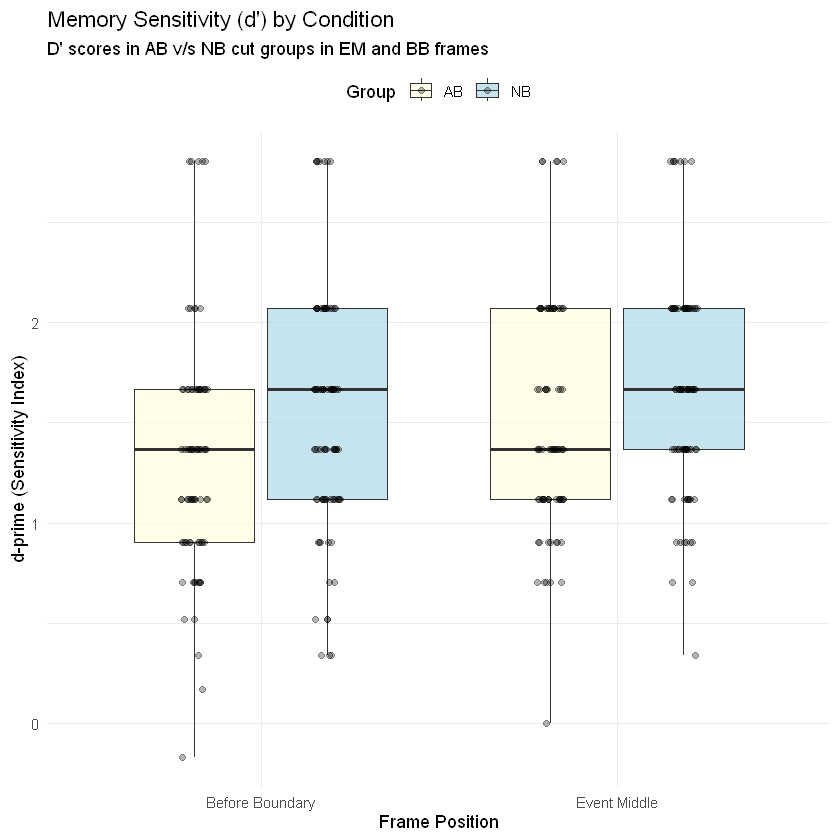

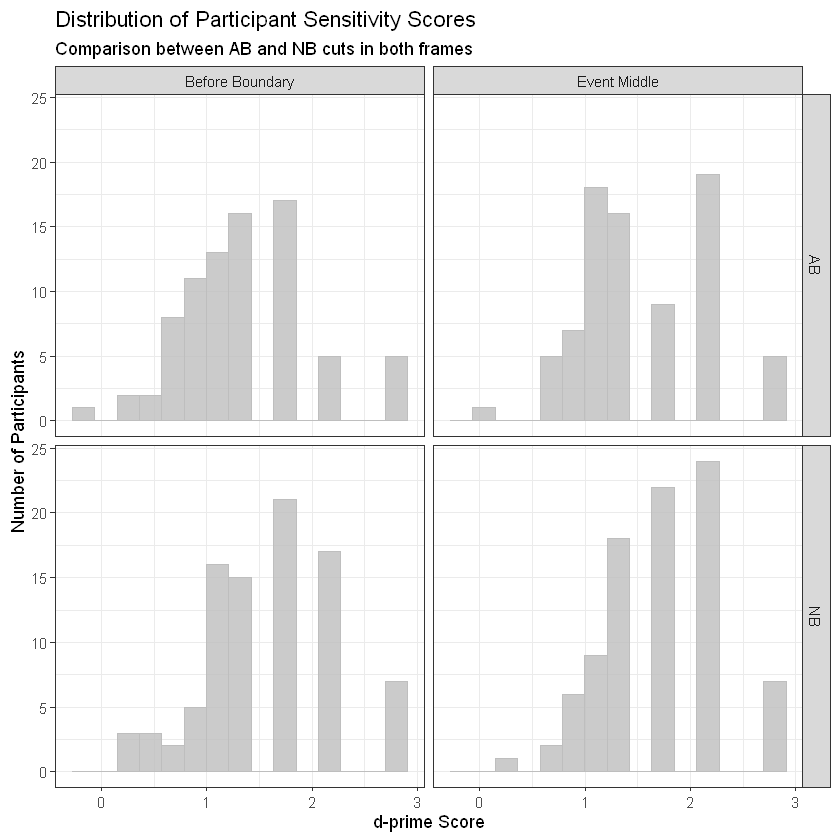

In [55]:

p1 <- ggplot(subject_summary, aes(x = FrameType, y = d_prime, fill = Condition)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +
  
  geom_point(position = position_jitterdodge(jitter.width = 0.15), 
             alpha = 0.3, size = 1.5) +
  theme_minimal() +
  labs(
    title = "Memory Sensitivity (d') by Condition",
    subtitle = "D' scores in AB v/s NB cut groups in EM and BB frames",
    x = "Frame Position",
    y = "d-prime (Sensitivity Index)",
    fill = "Group"
  ) +
  scale_fill_manual(values = c("AB" = "lightyellow", "NB" = "lightblue")) +
  theme(legend.position = "top")


p2 <- ggplot(subject_summary, aes(x = d_prime, fill = Condition)) +
  geom_histogram(alpha = 0.8, bins = 15, color = "grey") + 
  facet_grid(Condition ~ FrameType) + 
  theme_bw() +
  labs(
    title = "Distribution of Participant Sensitivity Scores",
    subtitle = "Comparison between AB and NB cuts in both frames",
    x = "d-prime Score",
    y = "Number of Participants"
  ) +
  scale_fill_manual(values = c("AB" = "grey", "NB" = "grey")) +
  theme(legend.position = "none") 


print(p1)
print(p2)

In [56]:
# Combine the dataframes
combined_accuracy <- rbind(abrupt_accuracy, natural_accuracy)
combined_accuracy

subject,accuracy,group
<chr>,<dbl>,<chr>
./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,0.975,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,0.825,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,0.850,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,0.850,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,0.825,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,0.750,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub106_AB_recognitionstage_2026-01-31_11h08.02.537.csv,0.725,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub107_AB_recognitionstage_2026-01-31_11h41.29.873.csv,0.950,Abrupt
./BRSM data csv/BRSM data csv/BRSM data csv/sub108_AB_recognitionstage_2026-01-31_12h17.52.749.csv,0.750,Abrupt


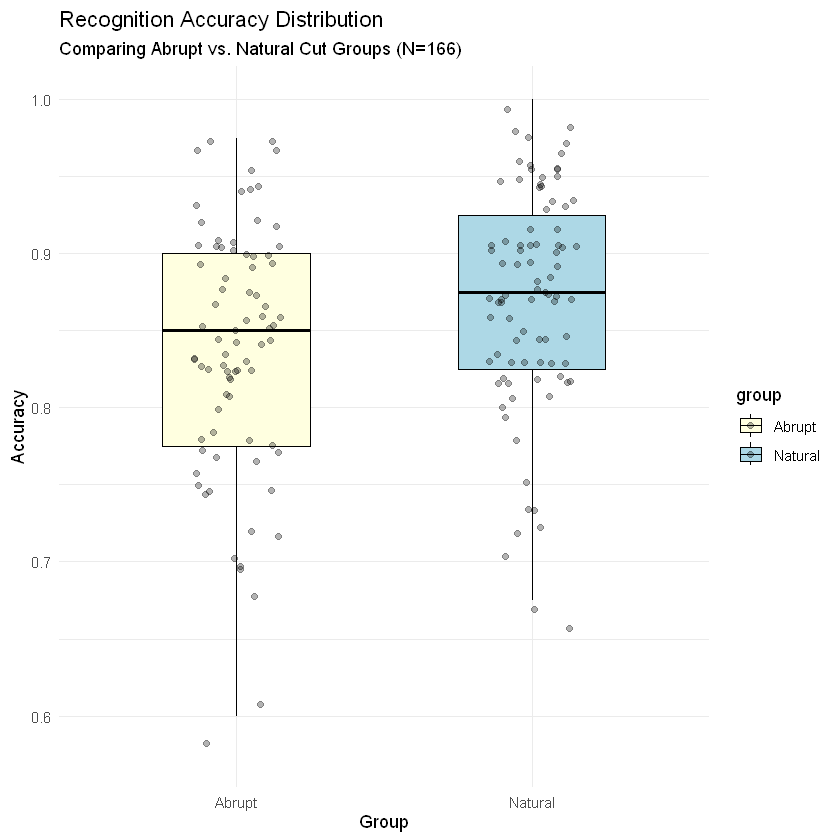

In [57]:
# box plot
ggplot(combined_accuracy, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [58]:
summary_table <- combined_accuracy %>%
  group_by(group) %>%
  summarize(
    Median_Value = median(accuracy, na.rm = TRUE),
    IQR_Value = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_table

group,Median_Value,IQR_Value,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.850,0.125,0.8376582,0.08222404,79
Natural,0.875,0.100,0.8704023,0.07269008,87


### Hypothesis Testing for Response Accuracy across two groups

H0: There is no significant difference in response accuracies of the two groups (Natural and Abrupt)  
  
HA: There is a significant difference in the response accuracies of the two groups (Two-tailed test)

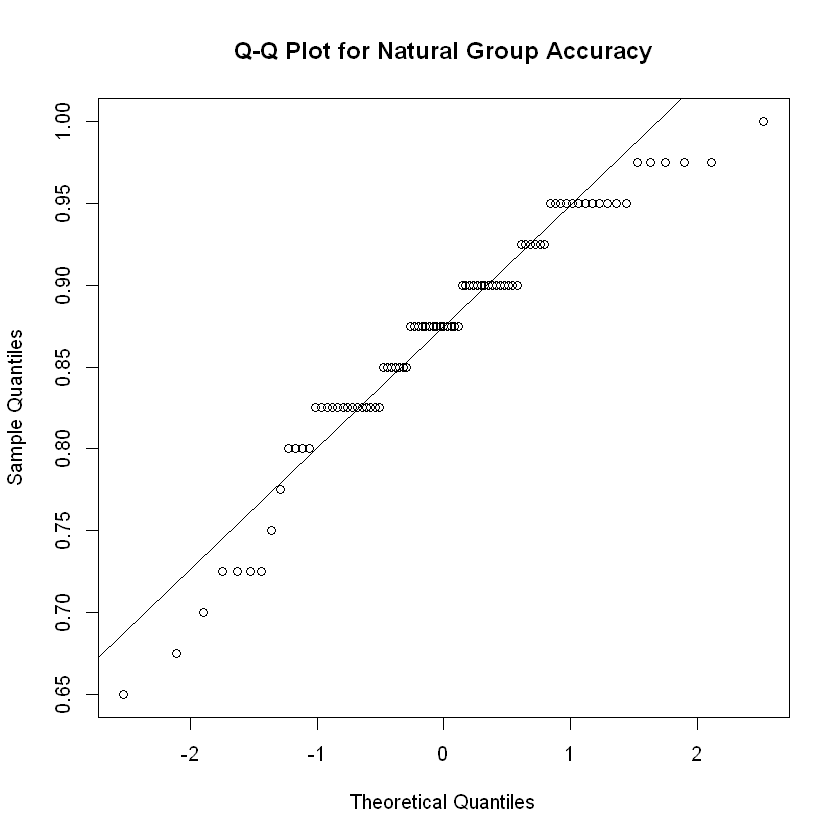

In [59]:
# Q-Q plot for Natural group
qqnorm(combined_accuracy$accuracy[combined_accuracy$group == "Natural"], main = "Q-Q Plot for Natural Group Accuracy")
qqline(combined_accuracy$accuracy[combined_accuracy$group == "Natural"])

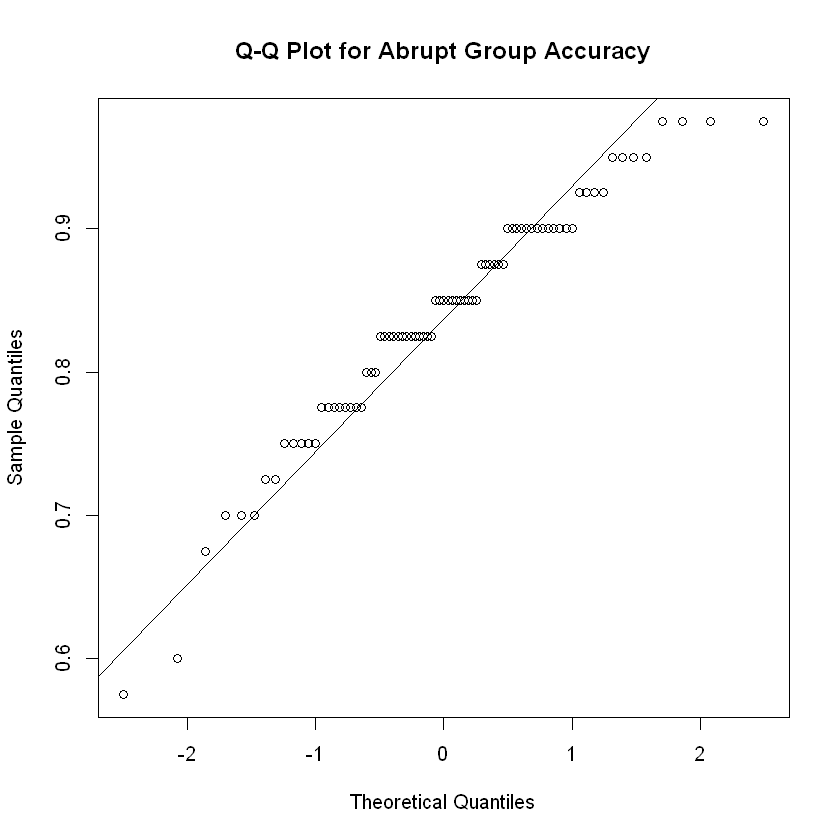

In [60]:
# Q-Q plot for Abrupt Group
qqnorm(combined_accuracy$accuracy[combined_accuracy$group == "Abrupt"], main = "Q-Q Plot for Abrupt Group Accuracy")
qqline(combined_accuracy$accuracy[combined_accuracy$group == "Abrupt"])

The distinct step pattern is because many subjects have similar mean accuracy values and a plateau at the upper quantiles indicates a ceiling effect, where a significant portion of the sample achieved maximum or near-maximum accuracy. This clustering at the upper bound prevents the data from following a normal distribution, further justifying the use of the Mann-Whitney U test over parametric tests.

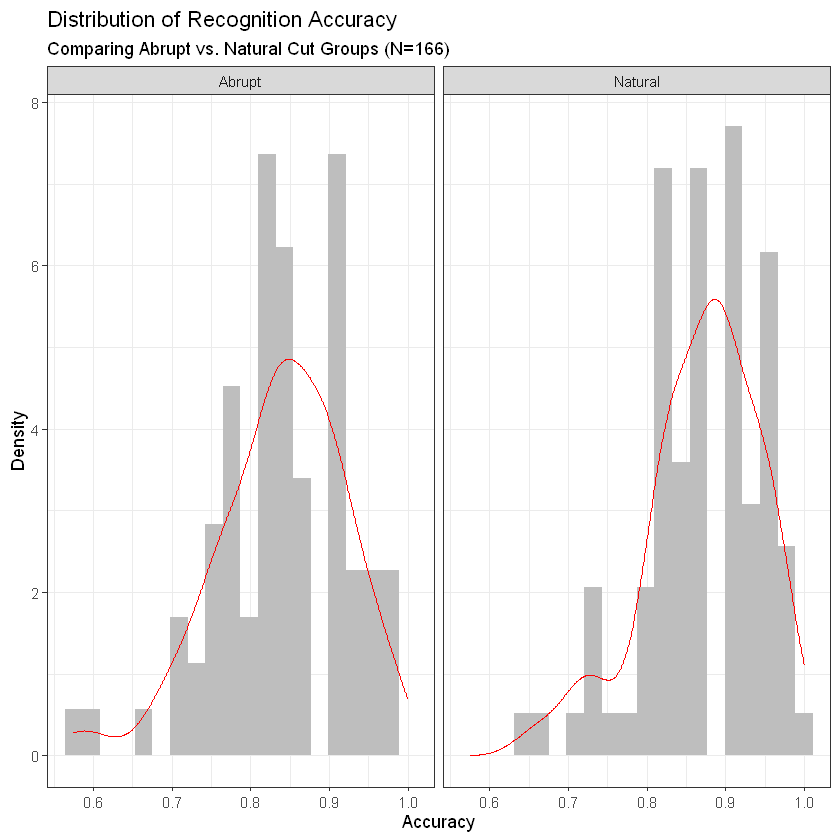

In [61]:
# Histogram of the response accuracy data for the two groups
ggplot(combined_accuracy, aes(x = accuracy)) +
  geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw() +
  labs(title = "Distribution of Recognition Accuracy",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       x = "Accuracy",
       y = "Density")

The above histogram plot shows the distribution of the Response Accuracy data across the two groups (Natural and Abrupt) along with Kernel Density Estimate (KDE) curves.

The distributions for both groups are negatively skewed, indicating a high frequency of successful outcomes. While both groups peak above 80% accuracy, the Natural group displays more high-accuracy results, whereas the Abrupt group shows slightly more variance and more lower-accuracy outliers.


In [62]:
# check normality
shapiro.test(combined_accuracy$accuracy[combined_accuracy$group == "Natural"])
shapiro.test(combined_accuracy$accuracy[combined_accuracy$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  combined_accuracy$accuracy[combined_accuracy$group == "Natural"]
W = 0.94194, p-value = 0.0006975



	Shapiro-Wilk normality test

data:  combined_accuracy$accuracy[combined_accuracy$group == "Abrupt"]
W = 0.95673, p-value = 0.009121


The results of the Shapiro-Wilk tests indicate that the response accuracy data for both variables/groups significantly deviate from a normal distribution (p < 0.05).  
  
The Mann-Whitney U test (or Wilcoxon Rank-Sum test) was therefore selected to compare the Natural and Abrupt groups for response accuracy.

In [63]:
# To check whether difference in accuracy is accounted for by the type of videos shown (abruptly cut/natural cut)
acc_wilcox_res <- wilcox.test(accuracy ~ group, data = combined_accuracy, conf.int = TRUE, exact = FALSE)
print(acc_wilcox_res)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2618.5, p-value = 0.007777
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -5.007096e-02 -7.971581e-05
sample estimates:
difference in location 
            -0.0250681 



In [64]:
# Effect size calculation
wilcox_effsize(combined_accuracy, accuracy ~ group)

,.y.,group1,group2,effsize,n1,n2,magnitude
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<ord>
Effect size (r),accuracy,Abrupt,Natural,0.2067073,79,87,small


In [65]:
# One tailed test to check if natural cut group has higher accuracy than abrupt cut group
acc_wilcox_res_onetailed <- wilcox.test(accuracy ~ group, data = combined_accuracy, conf.int = TRUE, exact = FALSE, alternative = "less")
print(acc_wilcox_res_onetailed)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2618.5, p-value = 0.003888
alternative hypothesis: true location shift is less than 0
95 percent confidence interval:
          -Inf -6.065601e-05
sample estimates:
difference in location 
            -0.0250681 



In [66]:
levels(factor(combined_accuracy$group))

[1] "Abrupt"  "Natural"

A Mann-Whitney U test was conducted to compare response accuracy between the Natural and Abrupt groups (n=171). The results indicated that the Natural group achieved significantly higher response accuracy (Median = 0.875) compared to the Abrupt group (Median = 0.85), W = 2770.5, p = 0.0088. The effect size (r = 0.20) represents a small-to-medium practical impact.

## Calculating Mean Response Time

A correct response reflects the speed of successful information processing. An error often reflects a "fast guess" (low RT) or a momentary lapse in attention/distraction (high RT). If one group (e.g., Abrupt cuts) has faster RTs but significantly more errors, they might just be rushing. Including those fast, incorrect RTs would falsely make the group look "more efficient" than they actually are.

In [67]:
# Calculation of mean response time
get_mean_rt <- function(filepath) {
  df <- read.csv(filepath)
  df <- df %>%
    filter(resp.corr == 1)
  rt_vector <- df %>%
    pull(resp.rt)
  rt_vector <- rt_vector[!is.na(rt_vector) & rt_vector != ""]
  numeric_rt <- parse_number(as.character(rt_vector))
  mean_rt <- mean(numeric_rt, na.rm = TRUE)
  return(mean_rt)
}


In [68]:
abrupt_rt_mean <- lapply(abrupt_files, get_mean_rt)
abrupt_rt_mean_df <- data.frame(
  subject = abrupt_files,
  mean_rt = unlist(abrupt_rt_mean),
  group = "Abrupt",
  stringsAsFactors = FALSE)
head(abrupt_rt_mean_df)

,subject,mean_rt,group
,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,9.409506,Abrupt
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,5.306544,Abrupt
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,4.724642,Abrupt
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,4.201918,Abrupt
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,3.733099,Abrupt
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,5.660510,Abrupt


In [69]:
natural_rt_mean <- lapply(natural_files, get_mean_rt)
natural_rt_mean_df <- data.frame(
  subject = natural_files,
  mean_rt = unlist(natural_rt_mean),
  group = "Natural",
  stringsAsFactors = FALSE)
head(natural_rt_mean_df)

,subject,mean_rt,group
,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub14_NB_recognitionstage_2026-01-18_09h03.10.088.csv,4.860804,Natural
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub15_NB_recognitionstage_2026-01-18_09h40.00.757.csv,4.995532,Natural
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub150_NB_recognitionstage_2026-02-03_11h41.50.843.csv,3.722461,Natural
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub152_NB_recognitionstage_2026-02-03_13h00.50.156.csv,9.393027,Natural
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub153_NB_recognitionstage_2026-02-03_14h52.04.936.csv,4.277758,Natural
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub154_NB_recognitionstage_2026-02-03_15h26.56.048.csv,4.473958,Natural


In [70]:
combined_mean_rt<- rbind(natural_rt_mean_df, abrupt_rt_mean_df)
head(combined_mean_rt)

,subject,mean_rt,group
,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub14_NB_recognitionstage_2026-01-18_09h03.10.088.csv,4.860804,Natural
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub15_NB_recognitionstage_2026-01-18_09h40.00.757.csv,4.995532,Natural
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub150_NB_recognitionstage_2026-02-03_11h41.50.843.csv,3.722461,Natural
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub152_NB_recognitionstage_2026-02-03_13h00.50.156.csv,9.393027,Natural
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub153_NB_recognitionstage_2026-02-03_14h52.04.936.csv,4.277758,Natural
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub154_NB_recognitionstage_2026-02-03_15h26.56.048.csv,4.473958,Natural


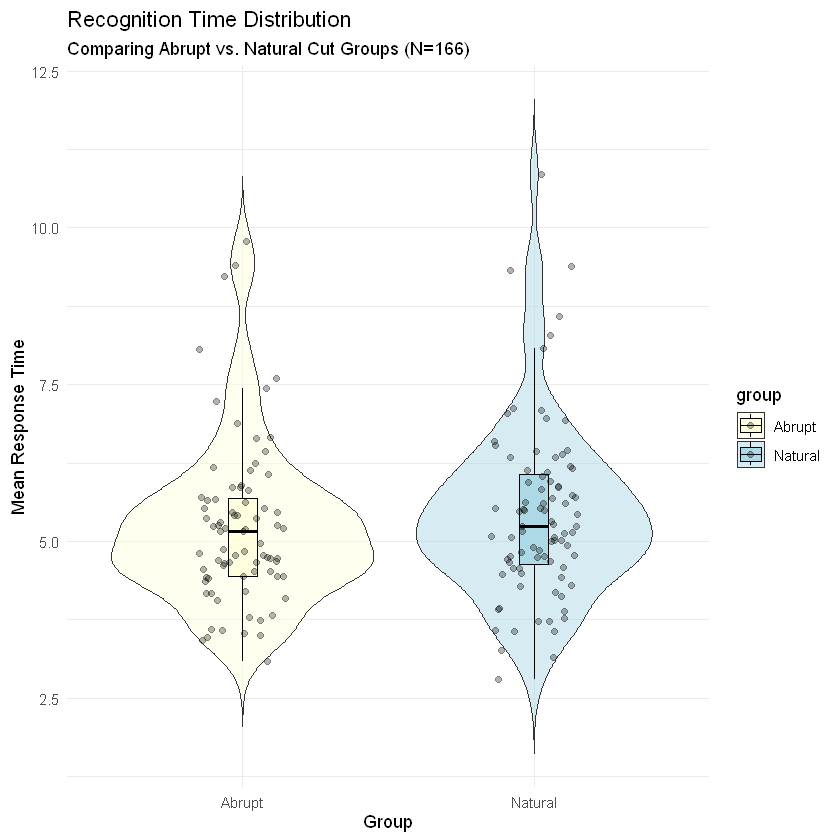

In [71]:
# violin plot
ggplot(combined_mean_rt, aes(x = group, y = mean_rt, fill = group)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.1, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Recognition Time Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Mean Response Time",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [72]:
summary_table <- combined_mean_rt %>%
  group_by(group) %>%
  summarize(
    n = n(),
    Median = median(mean_rt, na.rm = TRUE),
    IQR = IQR(mean_rt, na.rm = TRUE),
    Min = min(mean_rt, na.rm = TRUE),
    Max = max(mean_rt, na.rm = TRUE)
  )

summary_table

group,n,Median,IQR,Min,Max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Abrupt,79,5.150747,1.237653,3.077296,9.779291
Natural,87,5.237959,1.444568,2.790255,10.858324


### Hypothesis Testing for Response Time across the two groups   
  
H0: There is no significant difference in response times of the two groups (Natural and Abrupt)  
  
HA: There is a significant difference in the response times of the two groups (Two-tailed test)

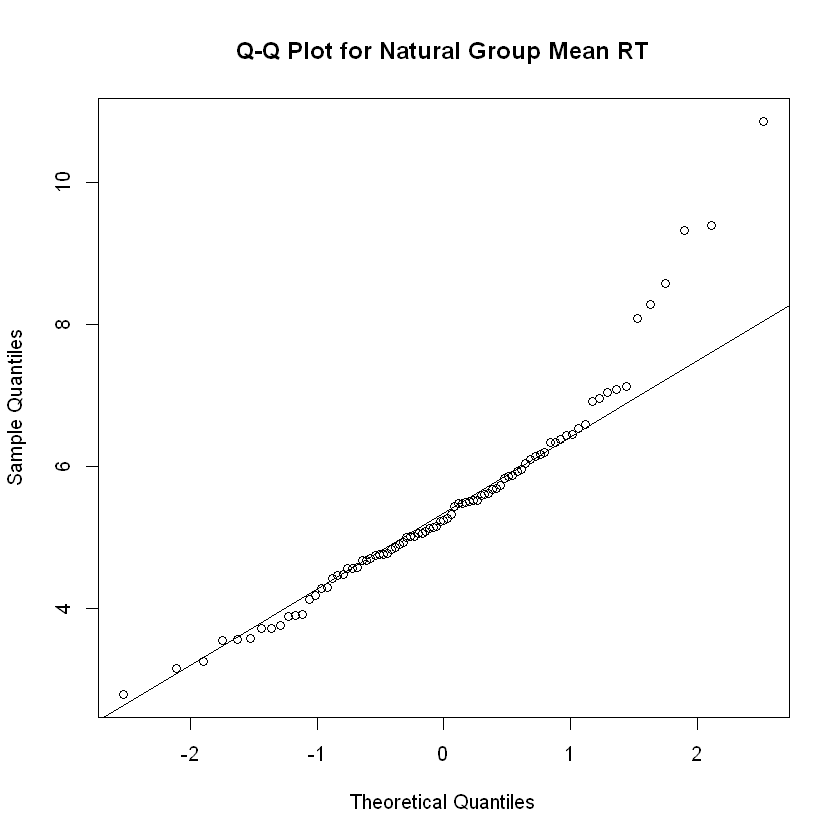

In [73]:
# Q-Q plot for Natural group
qqnorm(combined_mean_rt$mean_rt[combined_mean_rt$group == "Natural"], main = "Q-Q Plot for Natural Group Mean RT")
qqline(combined_mean_rt$mean_rt[combined_mean_rt$group == "Natural"])

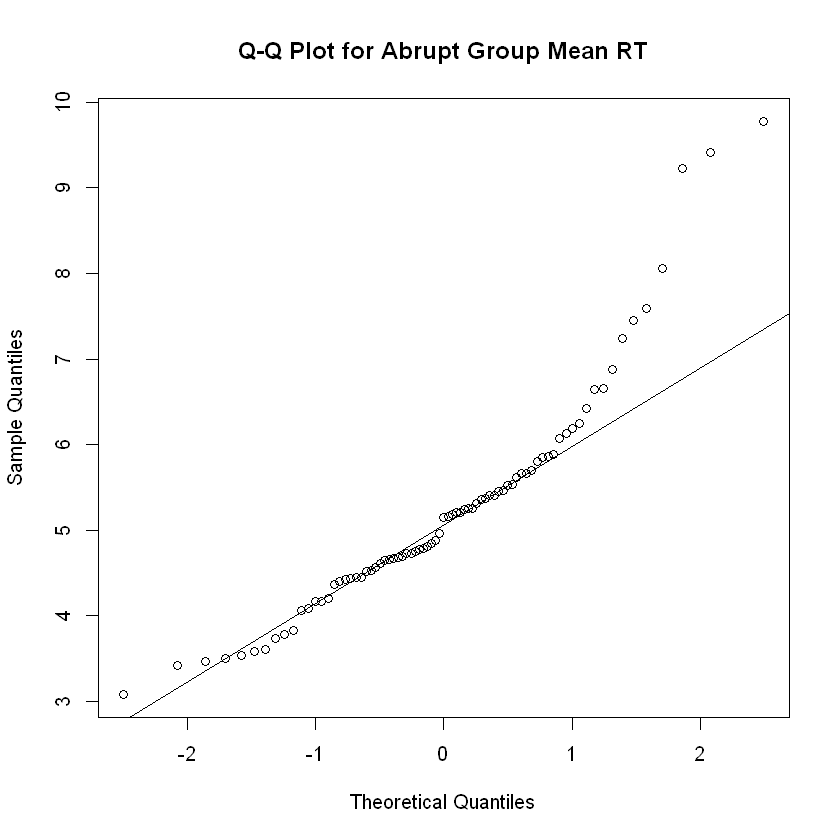

In [74]:
# Q-Q plot for Natural group
qqnorm(combined_mean_rt$mean_rt[combined_mean_rt$group == "Abrupt"], main = "Q-Q Plot for Abrupt Group Mean RT")
qqline(combined_mean_rt$mean_rt[combined_mean_rt$group == "Abrupt"])

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."


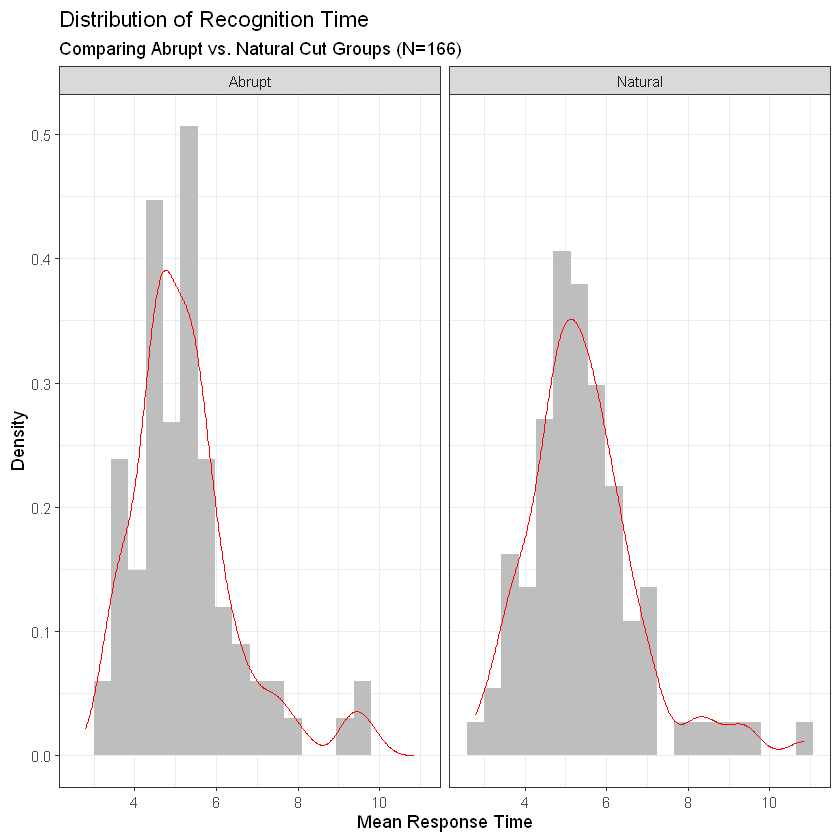

In [75]:
ggplot(combined_mean_rt, aes(x = mean_rt)) +
  geom_histogram(aes(y = ..density..), bins = 20, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw()+
  labs(title = "Distribution of Recognition Time",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       x = "Mean Response Time",
       y = "Density")

The response time can be lower in the abrupt group in case the subjects

In [76]:
# check normality
shapiro.test(combined_mean_rt$mean_rt[combined_mean_rt$group == "Natural"])
shapiro.test(combined_mean_rt$mean_rt[combined_mean_rt$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  combined_mean_rt$mean_rt[combined_mean_rt$group == "Natural"]
W = 0.92684, p-value = 0.0001059



	Shapiro-Wilk normality test

data:  combined_mean_rt$mean_rt[combined_mean_rt$group == "Abrupt"]
W = 0.89947, p-value = 1.296e-05


The results of the Shapiro-Wilk tests indicate that the response time data for both variables/groups significantly deviate from a normal distribution (p < 0.05).

The Mann-Whitney U test (or Wilcoxon Rank-Sum test) was therefore selected to compare the Natural and Abrupt groups for response time.

In [77]:
test_res <- wilcox.test(mean_rt ~ group, combined_mean_rt, conf.int = TRUE, exact = FALSE)
print(test_res)


	Wilcoxon rank sum test with continuity correction

data:  mean_rt by group
W = 3045, p-value = 0.2061
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -0.5528534  0.1325524
sample estimates:
difference in location 
             -0.220379 



A Mann-Whitney U test was conducted to compare response time between the Natural and Abrupt groups (n = 171). The p-value was 0.1594 indicating that the differences in response time between the Natural and Abrupt groups were not statistically significant.

Although the median response time for the Natural group is higher, the 0.1 p-value suggests this could be due to noise or individual variation within your 171 subjects.

The results demonstrate that while the Natural group exhibited significantly higher accuracy (p = 0.0088), their response times were statistically comparable to the Abrupt group (p = 0.1595). This suggests that Natural Cut videos facilitate better information processing leading to higher accuracy but do not necessarily lead to a quicker response time.

### Q2. Boundary-related Memory Effects

Computing Abrupt and Natural Group Event-Middle (EM) Response Accuracy

In [78]:
# Calculation of BB accuracy from resp.corr
get_EM_accuracy <- function(filepath, group_label) {
  df <- read.csv(filepath)

  df %>%
    filter(grepl("EM", target_img)) %>%
    summarise(
      EM_accuracy = mean(as.numeric(resp.corr), na.rm = TRUE)
    ) %>%
    mutate(
      participant = basename(filepath),
      group = group_label
    )
}

In [79]:
NB_EM <- bind_rows(lapply(natural_files, get_EM_accuracy, group = "Natural"))
AB_EM <- bind_rows(lapply(abrupt_files, get_EM_accuracy, group = "Abrupt"))

EM_data <- bind_rows(NB_EM, AB_EM)
head(EM_data)

,EM_accuracy,participant,group
,<dbl>,<chr>,<chr>
1,0.75,sub14_NB_recognitionstage_2026-01-18_09h03.10.088.csv,Natural
2,0.85,sub15_NB_recognitionstage_2026-01-18_09h40.00.757.csv,Natural
3,0.95,sub150_NB_recognitionstage_2026-02-03_11h41.50.843.csv,Natural
4,0.80,sub152_NB_recognitionstage_2026-02-03_13h00.50.156.csv,Natural
5,0.75,sub153_NB_recognitionstage_2026-02-03_14h52.04.936.csv,Natural
6,0.95,sub154_NB_recognitionstage_2026-02-03_15h26.56.048.csv,Natural


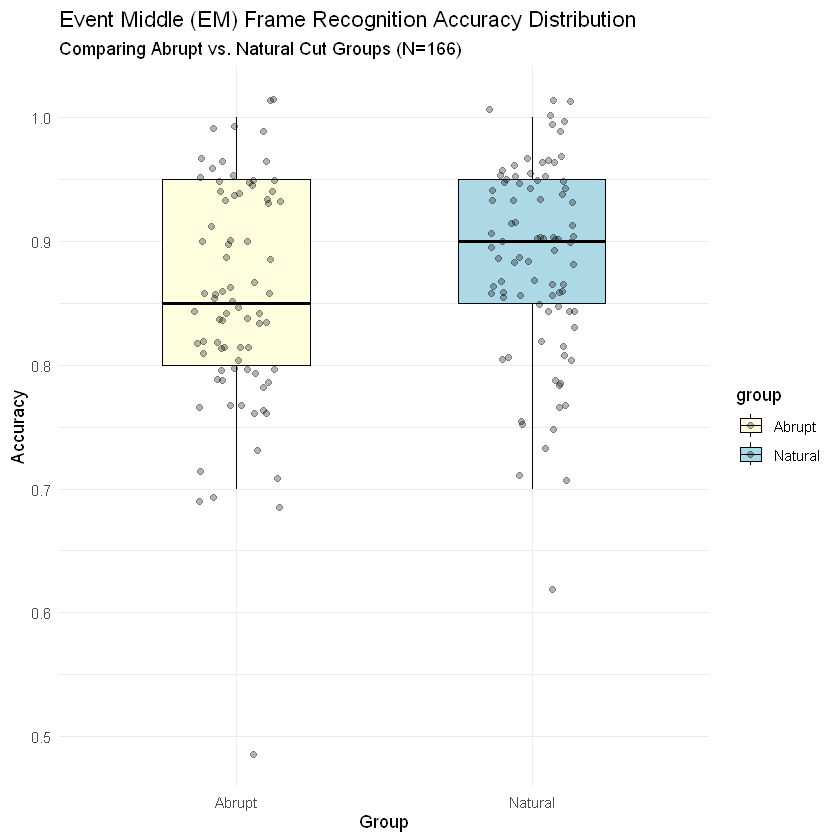

In [80]:
# box plot
ggplot(EM_data, aes(x = group, y = EM_accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Event Middle (EM) Frame Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [81]:
summary_EM <- EM_data %>%
  group_by(group) %>%
  summarize(
    median_accuracy = median(EM_accuracy, na.rm = TRUE),
    IQR = IQR(EM_accuracy, na.rm = TRUE),
    mean_accuracy = mean(EM_accuracy),
    sd_accuracy = sd(EM_accuracy),
    n = n())
summary_EM

group,median_accuracy,IQR,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.85,0.15,0.8537975,0.09260204,79
Natural,0.90,0.10,0.8827586,0.07954361,87


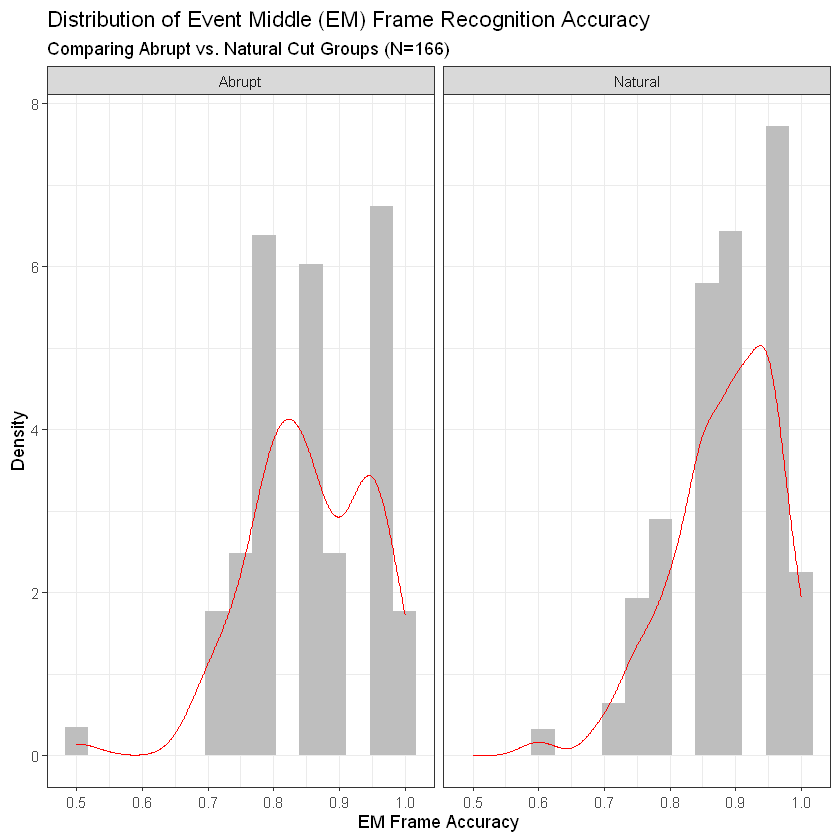

In [82]:
# Histogram of the EM response accuracy data for the two groups
ggplot(EM_data, aes(x = EM_accuracy)) +
  geom_histogram(aes(y = after_stat(density)), bins = 15, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw()+
  labs(title = "Distribution of Event Middle (EM) Frame Recognition Accuracy",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       x = "EM Frame Accuracy",
       y = "Density") 

In [83]:
# check normality
shapiro.test(EM_data$EM_accuracy[EM_data$group == "Natural"])
shapiro.test(EM_data$EM_accuracy[EM_data$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  EM_data$EM_accuracy[EM_data$group == "Natural"]
W = 0.91834, p-value = 3.965e-05



	Shapiro-Wilk normality test

data:  EM_data$EM_accuracy[EM_data$group == "Abrupt"]
W = 0.92256, p-value = 0.0001388


In [84]:
# To check whether difference in EM accuracy is accounted for by the type of videos shown (abruptly cut/natural cut)
EM_wilcox_res <- wilcox.test(EM_accuracy ~ group, data = EM_data, conf.int = TRUE, exact = FALSE)
print(EM_wilcox_res)


	Wilcoxon rank sum test with continuity correction

data:  EM_accuracy by group
W = 2785.5, p-value = 0.03215
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -0.0500160937 -0.0000070072
sample estimates:
difference in location 
           -0.04998322 



In [85]:
# one tailed test to check if natural cut group has higher EM accuracy than abrupt cut group
EM_wilcox_res_onetailed <- wilcox.test(EM_accuracy ~ group, data = EM_data, conf.int = TRUE, exact = FALSE, alternative = "less")
print(EM_wilcox_res_onetailed)


	Wilcoxon rank sum test with continuity correction

data:  EM_accuracy by group
W = 2785.5, p-value = 0.01608
alternative hypothesis: true location shift is less than 0
95 percent confidence interval:
          -Inf -3.604322e-05
sample estimates:
difference in location 
           -0.04998322 



In [86]:
levels(factor(EM_data$group))

[1] "Abrupt"  "Natural"

Computing Abrupt and Natural Group Before-boundary (BB) Response Accuracy

In [87]:
# Calculation of BB accuracy from resp.corr
get_BB_accuracy <- function(filepath, group_label) {
  df <- read.csv(filepath)
  df %>%
    filter(grepl("BB", target_img)) %>%
    summarise(
      BB_accuracy = mean(as.numeric(resp.corr), na.rm = TRUE)
    ) %>%
    mutate(
      participant = basename(filepath),
      group = group_label
    )
}

In [88]:
NB_BB <- bind_rows(lapply(natural_files, get_BB_accuracy, group = "Natural"))
AB_BB <- bind_rows(lapply(abrupt_files, get_BB_accuracy, group = "Abrupt"))

BB_data <- bind_rows(NB_BB, AB_BB)
BB_data

BB_accuracy,participant,group
<dbl>,<chr>,<chr>
0.90,sub14_NB_recognitionstage_2026-01-18_09h03.10.088.csv,Natural
0.75,sub15_NB_recognitionstage_2026-01-18_09h40.00.757.csv,Natural
0.75,sub150_NB_recognitionstage_2026-02-03_11h41.50.843.csv,Natural
0.80,sub152_NB_recognitionstage_2026-02-03_13h00.50.156.csv,Natural
0.65,sub153_NB_recognitionstage_2026-02-03_14h52.04.936.csv,Natural
0.95,sub154_NB_recognitionstage_2026-02-03_15h26.56.048.csv,Natural
0.95,sub155_NB_recognitionstage_2026-02-03_16h00.40.391.csv,Natural
0.95,sub156_NB_recognitionstage_2026-02-03_16h33.55.123.csv,Natural
0.85,sub158_NB_recognitionstage_2026-02-03_17h52.27.058.csv,Natural


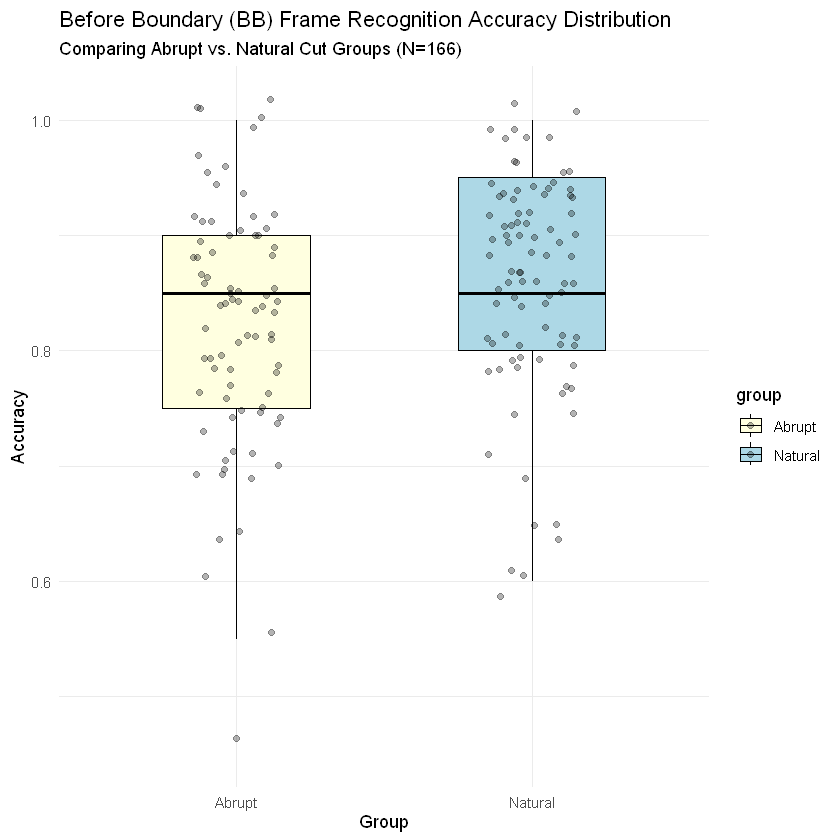

In [89]:
# box plot
ggplot(BB_data, aes(x = group, y = BB_accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Before Boundary (BB) Frame Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [90]:
summary_BB <- BB_data %>%
  group_by(group) %>%
  summarize(
    median_accuracy = median(BB_accuracy, na.rm = TRUE),
    IQR = IQR(BB_accuracy, na.rm = TRUE),
    mean_accuracy = mean(BB_accuracy),
    sd_accuracy = sd(BB_accuracy),
    n = n())
summary_BB

group,median_accuracy,IQR,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.85,0.15,0.821519,0.1046004,79
Natural,0.85,0.15,0.858046,0.0967115,87


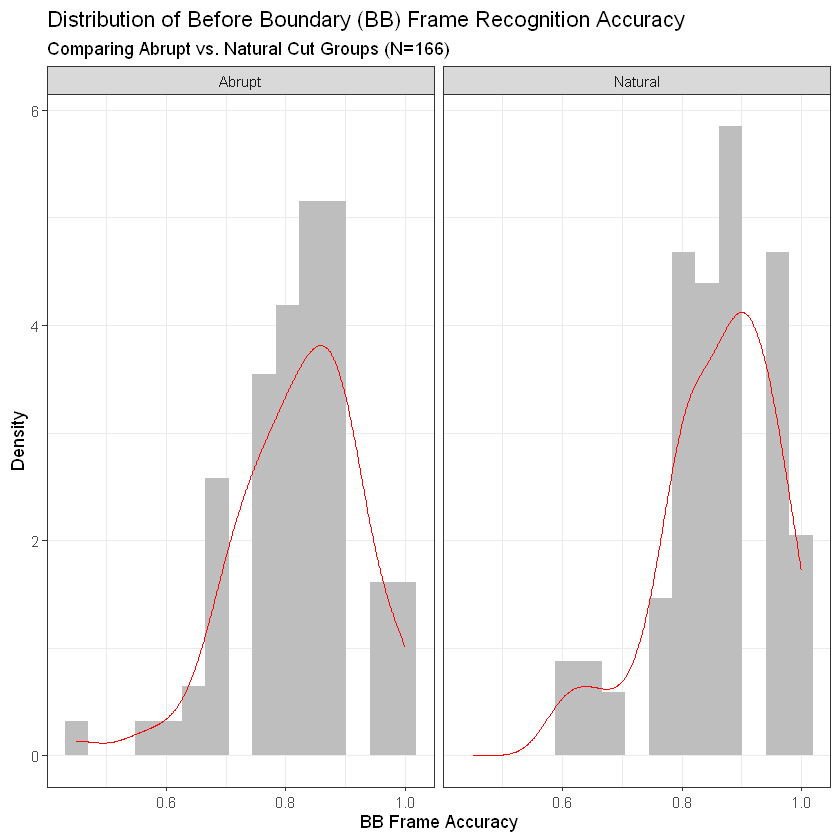

In [91]:
# Histogram of the EM response accuracy data for the two groups
ggplot(BB_data, aes(x = BB_accuracy)) +
  geom_histogram(aes(y = after_stat(density)), bins = 15, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw()+
  labs(title = "Distribution of Before Boundary (BB) Frame Recognition Accuracy",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       x = "BB Frame Accuracy",
       y = "Density")

In [92]:
# check normality
shapiro.test(BB_data$BB_accuracy[BB_data$group == "Natural"])
shapiro.test(BB_data$BB_accuracy[BB_data$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  BB_data$BB_accuracy[BB_data$group == "Natural"]
W = 0.92182, p-value = 5.89e-05



	Shapiro-Wilk normality test

data:  BB_data$BB_accuracy[BB_data$group == "Abrupt"]
W = 0.94746, p-value = 0.002669


In [93]:
# To check whether difference in BB accuracy is accounted for by the type of videos shown (abruptly cut/natural cut)
BB_wilcox_res <- wilcox.test(BB_accuracy ~ group, data = BB_data, conf.int = TRUE, exact = FALSE)
print(BB_wilcox_res)


	Wilcoxon rank sum test with continuity correction

data:  BB_accuracy by group
W = 2680.5, p-value = 0.01334
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -5.003880e-02 -1.421255e-05
sample estimates:
difference in location 
           -0.04999325 



In [94]:
# one tailed test to check if natural cut group has higher BB accuracy than abrupt cut group
BB_wilcox_res_onetailed <- wilcox.test(BB_accuracy ~ group, data = BB_data, conf.int = TRUE, exact = FALSE, alternative = "less")
print(BB_wilcox_res_onetailed)


	Wilcoxon rank sum test with continuity correction

data:  BB_accuracy by group
W = 2680.5, p-value = 0.006668
alternative hypothesis: true location shift is less than 0
95 percent confidence interval:
          -Inf -6.415244e-05
sample estimates:
difference in location 
           -0.04999325 

